<a href="https://colab.research.google.com/github/teemus28/Machine-Learning/blob/main/Gaussian_transformations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1 Standardization
#2 MinMaxScaler

In [ ]:
import pandas as pd
import seaborn as sbn

In [ ]:
tips = sbn.load_dataset('tips')

In [ ]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: ylabel='total_bill'>

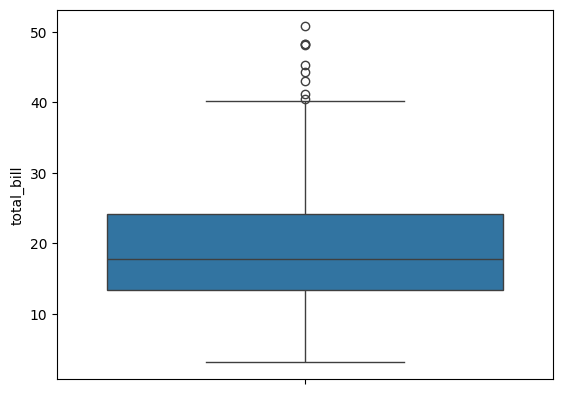

In [ ]:
sbn.boxplot(tips['total_bill'])

In [ ]:
#3 Robust Scaling
from sklearn.preprocessing import RobustScaler

In [ ]:
scale = RobustScaler()

In [ ]:
scale.fit(tips[['total_bill','tip']])

RobustScaler()

In [ ]:
tips_scale = scale.transform(tips[['total_bill','tip']])

In [ ]:
df = pd.DataFrame(tips_scale)

<Axes: >

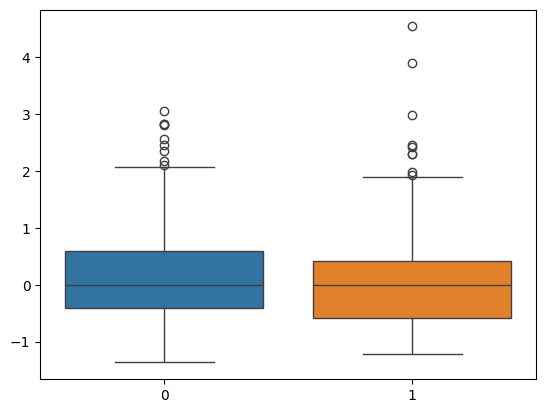

In [ ]:
sbn.boxplot(df)

In [ ]:
#4 Gaussian transformations

#logarithmic txn/s
#reciprocal txn/s
#square root txn/s
#exponential txn/s
#boxcox txn/s

#concrete dataset

In [ ]:
tips.sample()

,total_bill,tip,sex,smoker,day,time,size
21,20.29,2.75,Female,No,Sat,Dinner,2


In [ ]:
import scipy.stats as stat
import pylab
import matplotlib.pyplot as plt

In [ ]:
#checking whether the feature is normal or gaussian by Q-Q plot (quantile - quantile plots)
#if plots and line coincide then , it is gaussian

((array([-2.7660794 , -2.46319801, -2.29114787, -2.16825434, -2.07137443,
         -1.99075074, -1.9213089 , -1.86005848, -1.80508277, -1.75507658,
         -1.70910939, -1.66649348, -1.62670558, -1.58933792, -1.55406631,
         -1.52062855, -1.48880944, -1.45843008, -1.42934008, -1.40141172,
         -1.37453559, -1.34861722, -1.32357442, -1.29933525, -1.27583633,
         -1.25302156, -1.230841  , -1.20924999, -1.18820845, -1.16768023,
         -1.14763264, -1.12803597, -1.10886319, -1.09008958, -1.07169252,
         -1.0536512 , -1.03594646, -1.01856064, -1.00147737, -0.98468148,
         -0.96815887, -0.95189643, -0.93588192, -0.9201039 , -0.90455168,
         -0.88921522, -0.87408512, -0.85915251, -0.84440907, -0.82984693,
         -0.81545867, -0.80123728, -0.78717613, -0.77326892, -0.75950968,
         -0.74589275, -0.73241275, -0.71906453, -0.70584322, -0.69274417,
         -0.67976291, -0.66689521, -0.65413699, -0.64148438, -0.62893363,
         -0.61648119, -0.60412361, -0.

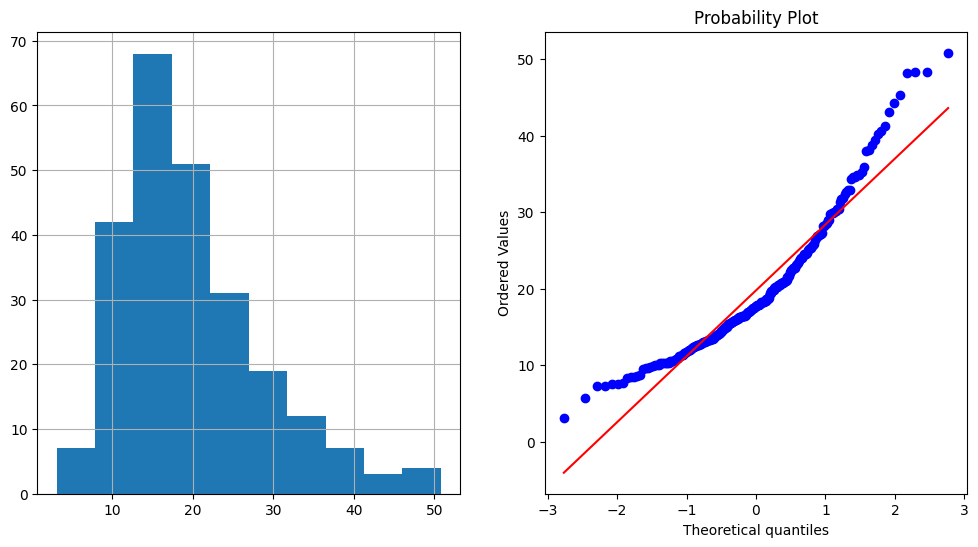

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
tips['total_bill'].hist()
plt.subplot(1,2,2)
stat.probplot(tips['total_bill'],dist='norm',plot=pylab)

In [ ]:
def plot_data(df,feature):
  plt.figure(figsize=(12,6))
  plt.subplot(1,2,1)
  df[feature].hist()
  plt.subplot(1,2,2)
  stat.probplot(df[feature],dist='norm',plot=pylab)


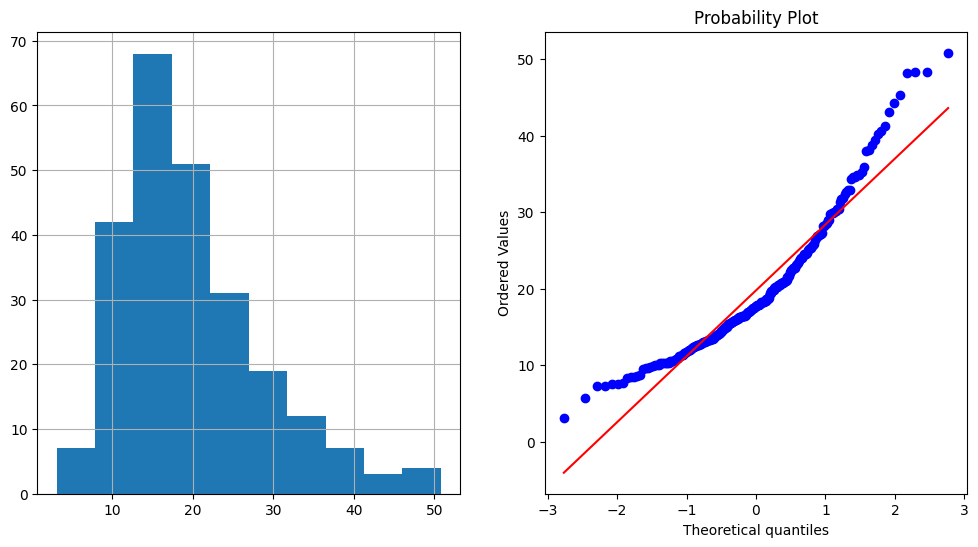

In [ ]:
plot_data(tips,'total_bill')

In [ ]:
#now we have to covert this to gaussian curve

1. Logarithmic transformations

In [ ]:
import numpy as np

In [ ]:
tips['total_bill_log']=np.log(tips['total_bill'])

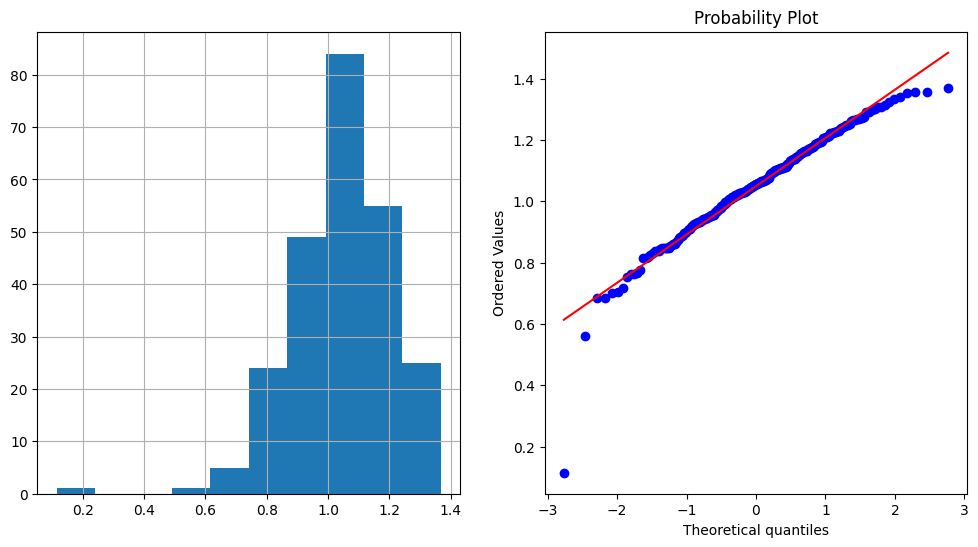

In [ ]:
plot_data(tips,'total_bill_log')

2. Reciprocal Transformations

In [ ]:
tips['total_bill_reciprocal'] = 1/tips['total_bill']

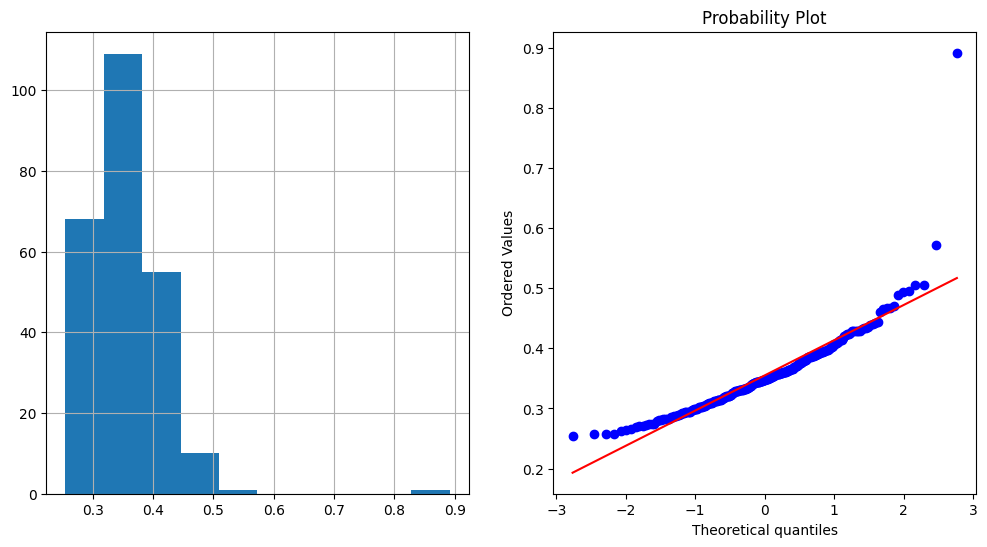

In [ ]:
plot_data(tips,'total_bill_reciprocal')

3. Square root transformations

In [ ]:
tips['total_bill_root']=tips['total_bill']*(1/2)

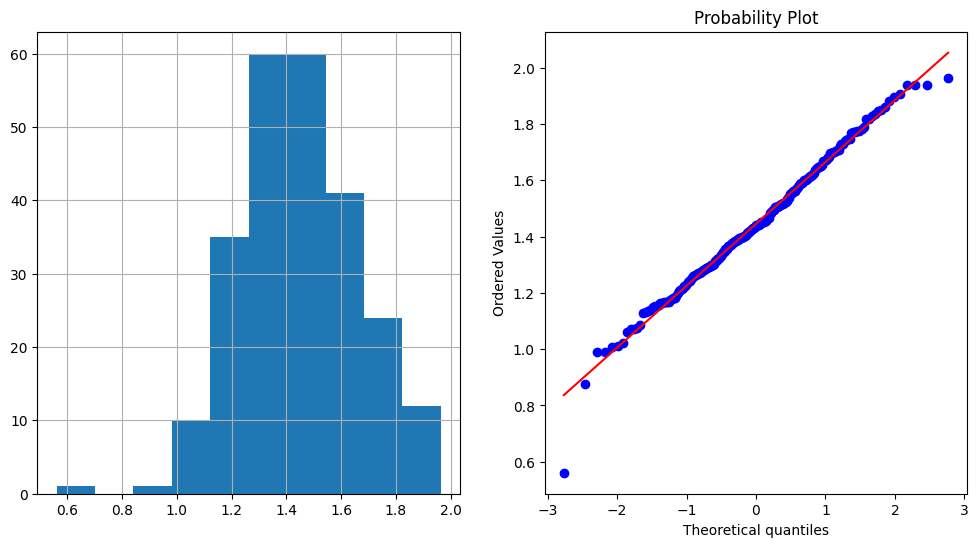

In [ ]:
plot_data(tips,'total_bill_root')

4. Exponential Transformations

In [ ]:
tips['total_bill_expo'] = tips['total_bill']**(1/1.2)

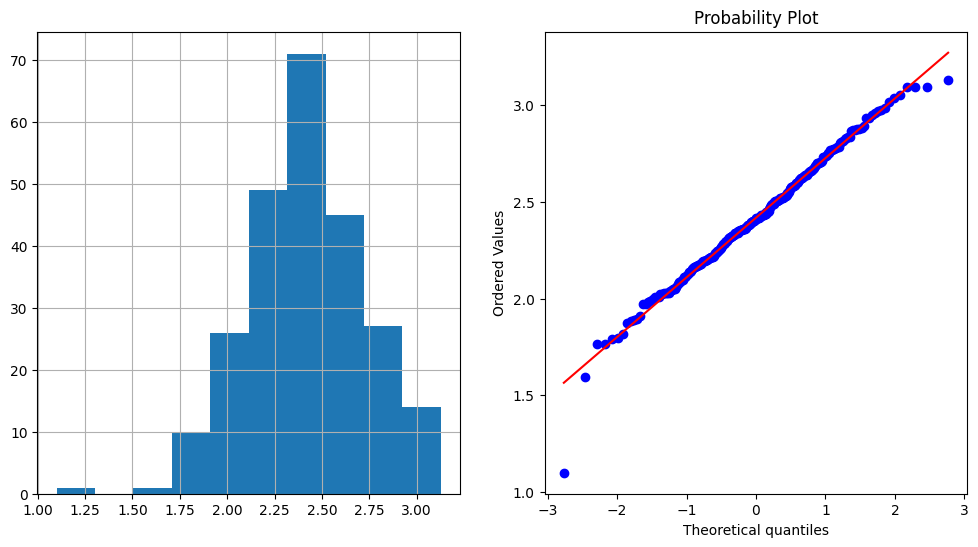

In [ ]:
plot_data(tips,'total_bill_expo')

5. BoxCox transformations

In [ ]:
#formula
# T(Y)=(Y exp(λ)−1)/λ
#Y - total_bill   , λ -  transformation parameter(-5 to 5)

In [ ]:
tips['total_bill_boxcox'],parameter=stat.boxcox(tips['total_bill'])

In [ ]:
parameter  # λ

1.2450694158936308

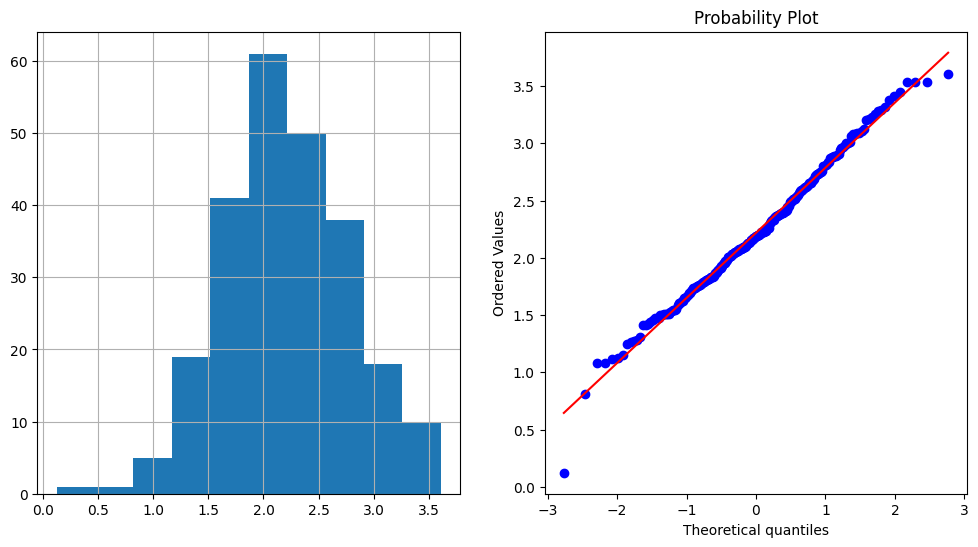

In [ ]:
plot_data(tips,'total_bill_boxcox')

In [ ]:
# yeo-johnsons transformation

In [ ]:
#choose txn which best fits with feature